In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("IMDB Dataset.csv")

In [3]:
df.duplicated().sum()

418

In [4]:
df=df.drop_duplicates()

In [5]:
#taking 10000 rows for analysis
df=df.iloc[:10000]

In [6]:
df['review']=df['review'].str.lower()

In [7]:
df['review']=df['review'].str.strip()

In [8]:
#remove html tags
df['review']=df['review'].str.replace(r'<.*?>','',regex=True)
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [9]:
df['review']=df['review'].str.replace(r"https?://\S+",'',regex=True)

In [10]:
import re

def remove_abb(text):
    text = str(text)  # Ensure input is a string

    # Clean bad encodings first
    text = re.sub(r"[\x89Ûªå«]+", "'", text)

    contractions = {
        r"\bI'm\b": "I am",
        r"\bhe's\b": "he is",
        r"\bshe's\b": "she is",
        r"\bit's\b": "it is",
        r"\bthat's\b": "that is",
        r"\bthere's\b": "there is",
        r"\bwe're\b": "we are",
        r"\bthey're\b": "they are",
        r"\bcan't\b": "cannot",
        r"\bwon't\b": "will not",
        r"\bdon't\b": "do not",
        r"\bdoesn't\b": "does not",
        r"\bdidn't\b": "did not",
        r"\baren't\b": "are not",
        r"\bisn't\b": "is not",
        r"\bhaven't\b": "have not",
        r"\bhasn't\b": "has not",
        r"\bwouldn't\b": "would not",
        r"\bshouldn't\b": "should not",
        r"\bcouldn't\b": "could not",
        r"\byou're\b": "you are",
        r"\byou've\b": "you have",
        r"\byou'll\b": "you will",
        r"\byou'd\b": "you would",
        r"\bi'm\b": "I am",
        r"\bi've\b": "I have",
        r"\bi'll\b": "I will",
        r"\bi'd\b": "I would",
        r"\blet's\b": "let us",
        r"\bwe've\b": "we have",
        r"\bthey've\b": "they have",
        r"\bthey'll\b": "they will",
        r"\bthey'd\b": "they would",
        r"\bwho's\b": "who is",
        r"\bwhat's\b": "what is",
        r"\bwhere's\b": "where is",
        r"\bain't\b": "am not",
        r"\by'all\b": "you all",
        r"\bwould've\b": "would have",
        r"\bshould've\b": "should have",
        r"\bcould've\b": "could have"
    }

    for pattern, replacement in contractions.items():
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)

    return text


In [11]:
df['review']=df['review'].apply(remove_abb)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10016
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     10000 non-null  object
 1   sentiment  10000 non-null  object
dtypes: object(2)
memory usage: 234.4+ KB


In [13]:
df['sentiment']=df['sentiment'].astype('category')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10016
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   review     10000 non-null  object  
 1   sentiment  10000 non-null  category
dtypes: category(1), object(1)
memory usage: 166.1+ KB


In [15]:
df['sentiment'].value_counts()

sentiment
positive    5030
negative    4970
Name: count, dtype: int64

In [16]:
!pip install textblob
from textblob import TextBlob

text = "hi I can drve at nigt"
TextBlob(text).correct().string

'hi I can drove at night'

In [17]:
def spelling_correction(text):
    return TextBlob(text).correct().string

In [18]:
import string
def remove_punctuation(text):
    for i in string.punctuation:
        if i in text:
            text=text.replace(i,'')
    return text

In [19]:
df['review']=df['review'].apply(remove_punctuation)
df['review'].head()

0    one of the other reviewers has mentioned that ...
1    a wonderful little production the filming tech...
2    i thought this was a wonderful way to spend ti...
3    basically there is a family where a little boy...
4    petter matteis love in the time of money is a ...
Name: review, dtype: object

In [20]:
from nltk.tokenize import word_tokenize
nltk.download('punkt')

<IPython.core.display.Javascript object>

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\swaya\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [21]:
from nltk.tokenize import word_tokenize

In [22]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab')  # Run once

df['tokenized_review'] = df['review'].apply(word_tokenize)


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\swaya\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [23]:
df

,review,sentiment,tokenized_review
0,one of the other reviewers has mentioned that ...,positive,"[one, of, the, other, reviewers, has, mentione..."
1,a wonderful little production the filming tech...,positive,"[a, wonderful, little, production, the, filmin..."
2,i thought this was a wonderful way to spend ti...,positive,"[i, thought, this, was, a, wonderful, way, to,..."
3,basically there is a family where a little boy...,negative,"[basically, there, is, a, family, where, a, li..."
4,petter matteis love in the time of money is a ...,positive,"[petter, matteis, love, in, the, time, of, mon..."
...,...,...,...
10012,i was pleasantly surprised to find that how to...,positive,"[i, was, pleasantly, surprised, to, find, that..."
10013,this is a very moving film that takes a new tw...,positive,"[this, is, a, very, moving, film, that, takes,..."
10014,apart from the beautiful imagery thanks to new...,negative,"[apart, from, the, beautiful, imagery, thanks,..."
10015,this is a perfect series for family viewing we...,positive,"[this, is, a, perfect, series, for, family, vi..."


In [24]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\swaya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [25]:
def remove_stopwords(text):
    
    L = []
    for word in text:
        if word not in stopwords.words('english'):
            L.append(word)
            
    return L

In [26]:
def remove_stopwords(text):
    from nltk.corpus import stopwords
    stop_words = set(stopwords.words('english'))
    return [word for word in text if word.lower() not in stop_words]


In [27]:
df['cleaned_review']=df['tokenized_review'].apply(remove_stopwords)

In [28]:
df

,review,sentiment,tokenized_review,cleaned_review
0,one of the other reviewers has mentioned that ...,positive,"[one, of, the, other, reviewers, has, mentione...","[one, reviewers, mentioned, watching, 1, oz, e..."
1,a wonderful little production the filming tech...,positive,"[a, wonderful, little, production, the, filmin...","[wonderful, little, production, filming, techn..."
2,i thought this was a wonderful way to spend ti...,positive,"[i, thought, this, was, a, wonderful, way, to,...","[thought, wonderful, way, spend, time, hot, su..."
3,basically there is a family where a little boy...,negative,"[basically, there, is, a, family, where, a, li...","[basically, family, little, boy, jake, thinks,..."
4,petter matteis love in the time of money is a ...,positive,"[petter, matteis, love, in, the, time, of, mon...","[petter, matteis, love, time, money, visually,..."
...,...,...,...,...
10012,i was pleasantly surprised to find that how to...,positive,"[i, was, pleasantly, surprised, to, find, that...","[pleasantly, surprised, find, lose, friends, a..."
10013,this is a very moving film that takes a new tw...,positive,"[this, is, a, very, moving, film, that, takes,...","[moving, film, takes, new, twist, somewhere, r..."
10014,apart from the beautiful imagery thanks to new...,negative,"[apart, from, the, beautiful, imagery, thanks,...","[apart, beautiful, imagery, thanks, new, zeala..."
10015,this is a perfect series for family viewing we...,positive,"[this, is, a, perfect, series, for, family, vi...","[perfect, series, family, viewing, gather, aro..."


In [29]:
df['review'] = df['cleaned_review'].apply(lambda x:" ".join(x))

In [30]:
df1=df[['review','sentiment']]

In [31]:
df1['char_len']=df1['review'].str.len()

C:\Users\swaya\AppData\Local\Temp\ipykernel_15692\2691707020.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['char_len']=df1['review'].str.len()


In [32]:
df1

,review,sentiment,char_len
0,one reviewers mentioned watching 1 oz episode ...,positive,1142
1,wonderful little production filming technique ...,positive,656
2,thought wonderful way spend time hot summer we...,positive,588
3,basically family little boy jake thinks zombie...,negative,440
4,petter matteis love time money visually stunni...,positive,863
...,...,...,...
10012,pleasantly surprised find lose friends alienat...,positive,668
10013,moving film takes new twist somewhere relation...,positive,413
10014,apart beautiful imagery thanks new zealand cin...,negative,1090
10015,perfect series family viewing gather around tv...,positive,1026


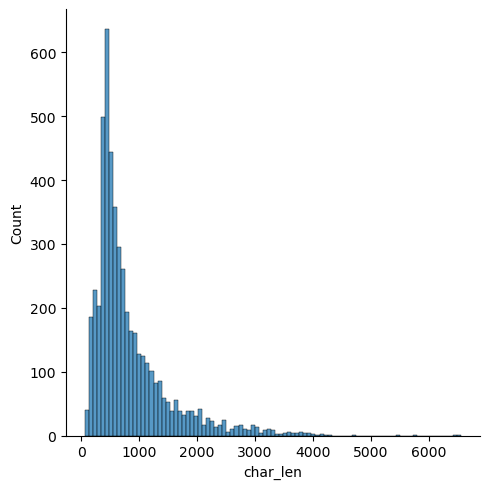

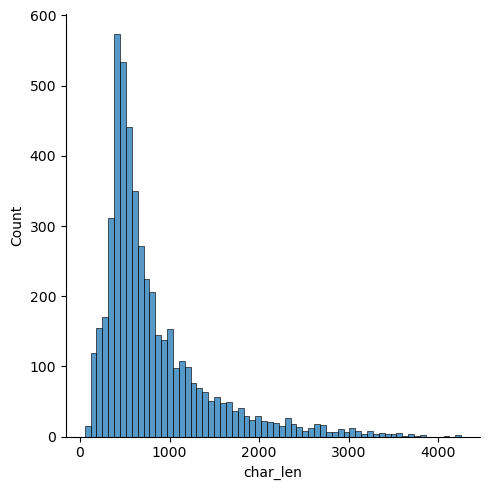

In [43]:
import seaborn as sns
sns.displot(df1[df1['sentiment'] == 'positive']['char_len'])
sns.displot(df1[df1['sentiment'] == 'negative']['char_len'])

In [ ]:
df['cleaned_review'].sum()

In [35]:
from nltk import ngrams

pd.Series(ngrams(df['cleaned_review'].sum(),2)).value_counts()

(ever, seen)           460
(special, effects)     438
(even, though)         372
(one, best)            348
(looks, like)          308
                      ... 
(body, crowned)          1
(crowned, hamilton)      1
(high, prom)             1
(queen, allows)          1
(hurt, yet)              1
Name: count, Length: 845388, dtype: int64

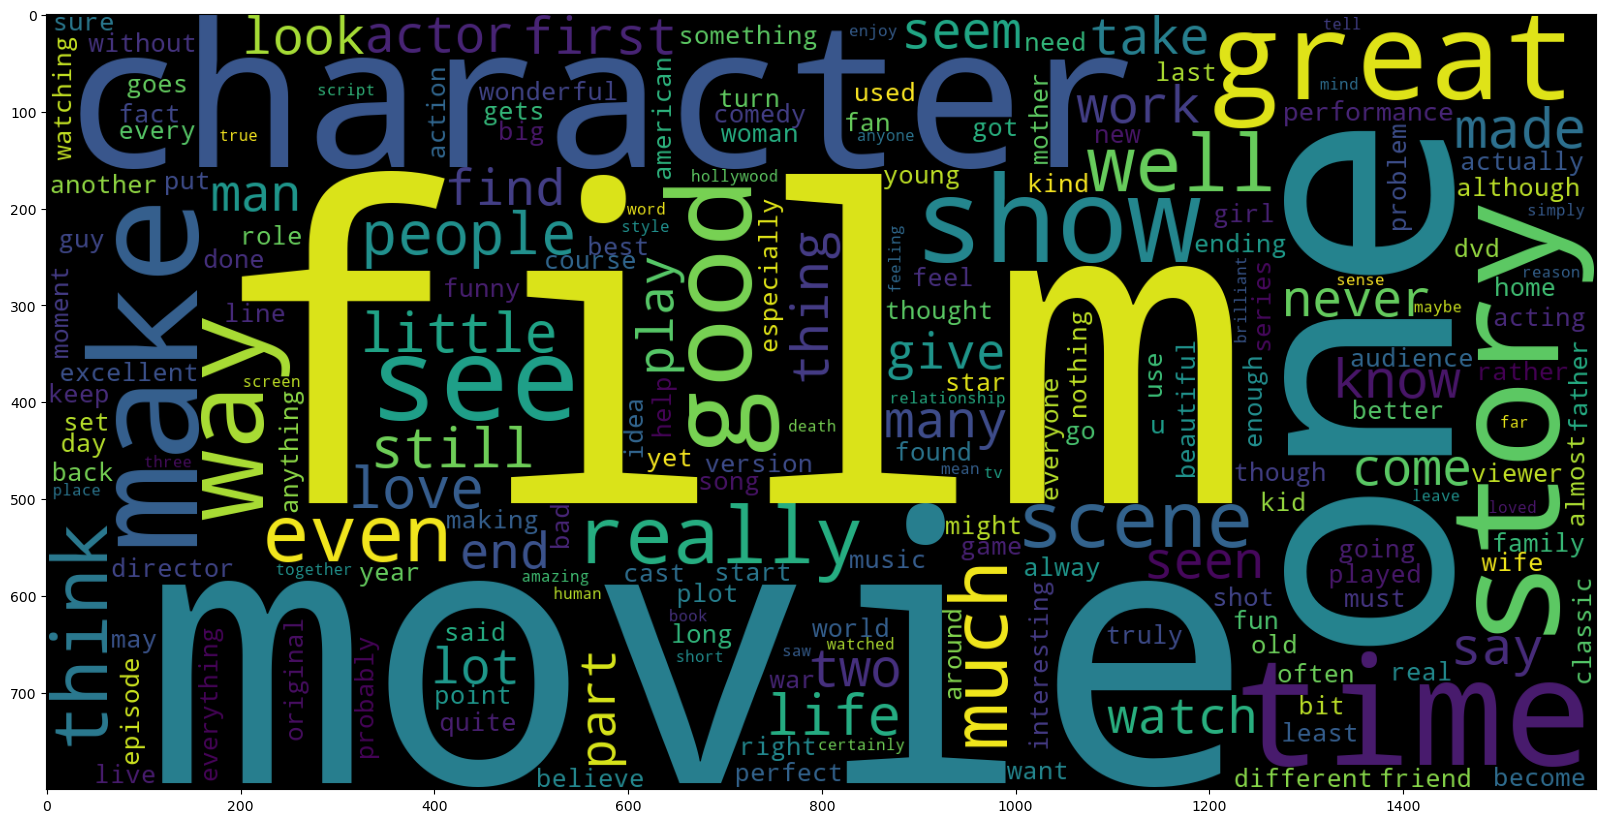

In [37]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

plt.figure(figsize = (20,20)) # Positive Review Text
wc = WordCloud(width = 1600 , height = 800).generate(" ".join(df[df['sentiment'] == 'positive']['review']))
plt.imshow(wc)

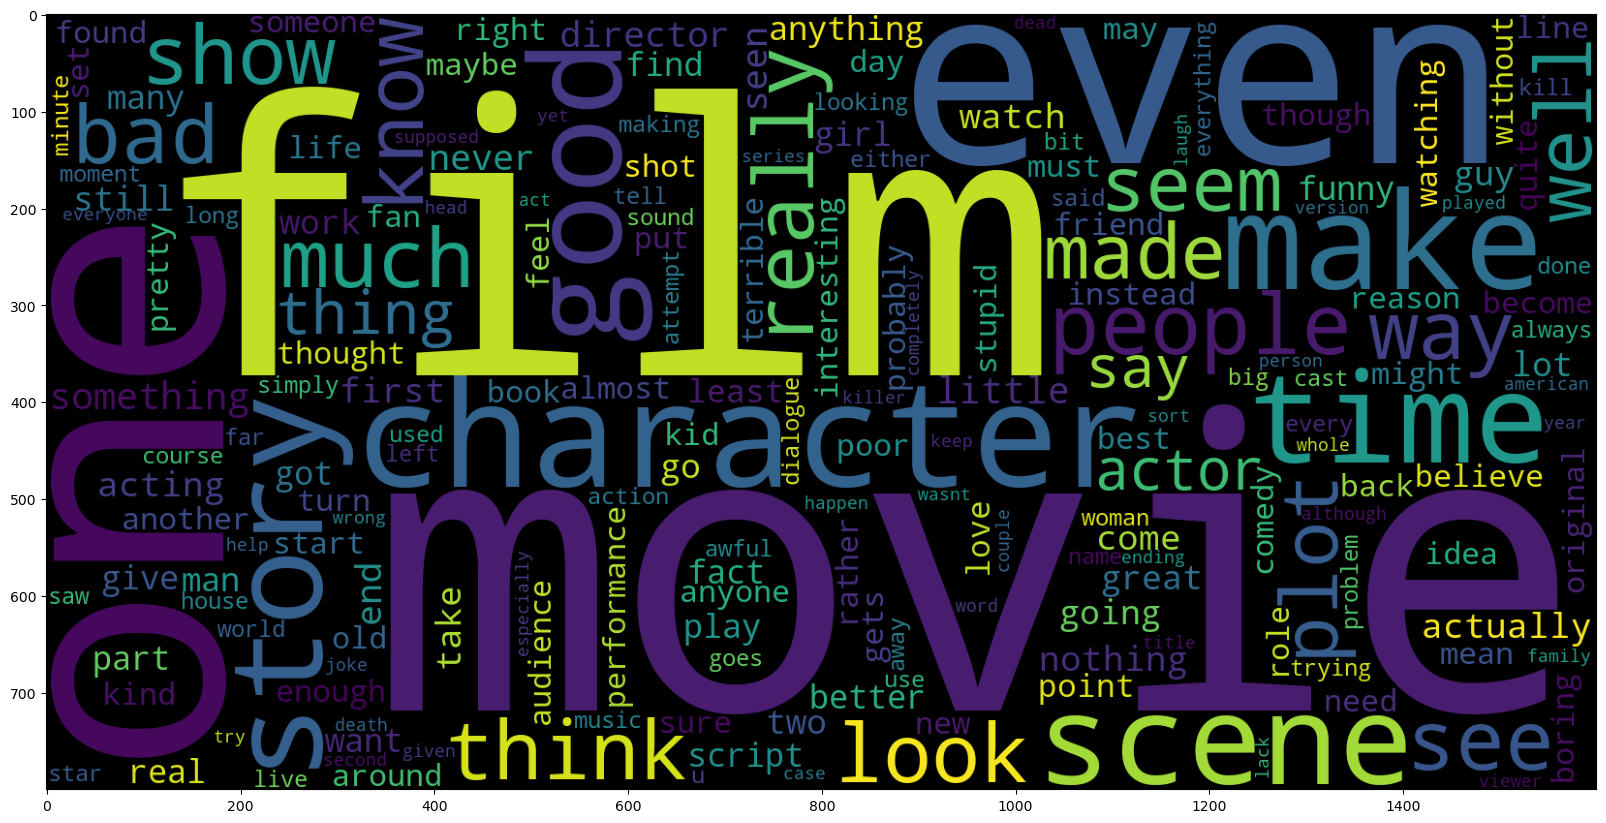

In [38]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

plt.figure(figsize = (20,20)) # Positive Review Text
wc = WordCloud(width = 1600 , height = 800).generate(" ".join(df[df['sentiment'] == 'negative']['review']))
plt.imshow(wc)

In [39]:
# BoW

from sklearn.feature_extraction.text import CountVectorizer
count_vectorizer = CountVectorizer(max_features=5000,ngram_range=(1,3))
bag_of_words = count_vectorizer.fit_transform(df['review'])
bag_of_words = pd.DataFrame(bag_of_words.toarray(),columns = count_vectorizer.get_feature_names_out())

In [40]:
bag_of_words

,10,10 10,10 minutes,10 years,100,1010,11,110,12,13,...,young girl,young man,young people,young woman,younger,youth,zero,zombie,zombies,zone
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [41]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(bag_of_words.values)

<IPython.core.display.Javascript object>

<Axes: >

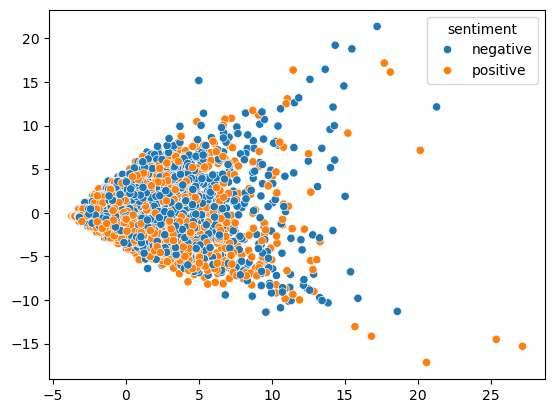

In [43]:
sns.scatterplot(x=pca_result[:,0],y=pca_result[:,1],hue=df['sentiment'])